In [1]:
import os, sys
project_root = os.path.abspath('..').replace('\\', '/')
if project_root not in [p.replace('\\', '/') for p in sys.path]:
    sys.path.append(project_root)


# 01 分箱模块 (core.binning)

基于 `hengshucredit_yyp.xlsx` 或 `hscredit_yyp.xlsx`（置于 `examples/`），覆盖常用分箱算法与参数。

**数据说明**:
- 样本与字段以实际 Excel 为准（典型约近千行、十余个字段）
- 演示目标: `target_demo`，由 `MOB1 > 3` 构造（若无 `MOB1` 则尝试 `FPD`）
- 单特征演示优先选用含 `C3` 的数值评分列

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
# import matplotlib; matplotlib.use('inline')
import matplotlib.pyplot as plt
import hscredit as hsc
from hscredit import init_setting, OptimalBinning
from hscredit import (
    UniformBinning, QuantileBinning, TreeBinning, ChiMergeBinning,
    BestKSBinning, BestIVBinning, MDLPBinning, CartBinning,
    KMeansBinning, MonotonicBinning, SmoothBinning,
    BestLiftBinning, TargetBadRateBinning,
)
init_setting()

from pathlib import Path
_roots = [Path.cwd(), Path.cwd() / 'examples', Path.cwd().parent]
_fp = None
for _r in _roots:
    for _n in ('hengshucredit_yyp.xlsx', 'hscredit_yyp.xlsx'):
        if (_r / _n).is_file():
            _fp = _r / _n
            break
    if _fp is not None:
        break
if _fp is None:
    raise FileNotFoundError('请将 hengshucredit_yyp.xlsx 或 hscredit_yyp.xlsx 放在 examples/')
df = pd.read_excel(_fp)

# 目标列：优先使用MOB1>3作为演示标签
if 'MOB1' not in df.columns:
    raise ValueError('示例需要 MOB1 列，请检查 hscredit_yyp.xlsx')

df['target_demo'] = (df['MOB1'] > 3).astype(int)
target = 'target_demo'

exclude_cols = {'MOB1', 'MOB2', 'target_demo'}
features = [c for c in df.columns if c not in exclude_cols]

# 自动挑一个数值特征做单特征演示（优先 C3）
def pick_feature(cols):
    for c in cols:
        s = str(c)
        if 'C3' in s or 'c3' in s:
            return c
    return cols[0]

feat = pick_feature(features)
print(f'样本数: {len(df):,}, 坏样本率: {df[target].mean():.2%}, 特征数: {len(features)}, 演示特征: {feat}')


## 0.1 单方法分箱质量对比

下面对 notebook 中常用方法做一个紧凑对比，重点关注：

- `n_bins`: 有效分箱数
- `quadratic_lift`: `LIFT值` 曲线二次项系数
- `zero_pair_count`: 是否存在相邻两箱坏样本率同时为 0
- `lift_seq`: 各箱 `LIFT值` 序列

这样可以更直观看到分箱排序质量，而不只是看 IV。

,rank,recommendation,method,n_bins,composite_score,quadratic_lift,zero_pair_count,splits,lift_seq,bad_rate_seq
0,1,推荐,target_bad_rate,5,2.4893,0.4531,0,"[492.0, 575.5, 676.0, 793.4]","[2.5661, 1.0519, 0.9254, 0.6438, 0.0]","[0.4286, 0.1757, 0.1545, 0.1075, 0.0]"
1,2,,cart,5,2.3551,0.4857,0,"[492.0, 544.5, 608.5, 689.0]","[2.5661, 1.3144, 1.0887, 0.7571, 0.4082]","[0.4286, 0.2195, 0.1818, 0.1264, 0.0682]"
2,3,,or_tools,5,2.2089,0.3073,0,"[494.0, 544.5, 687.0, 777.76]","[2.3951, 1.3472, 0.8926, 0.5821, 0.0]","[0.4, 0.225, 0.1491, 0.0972, 0.0]"
3,4,,best_iv,5,2.1832,0.3210,0,"[495.3, 593.0, 685.0, 793.4]","[2.2454, 1.131, 0.7485, 0.7392, 0.0]","[0.375, 0.1889, 0.125, 0.1235, 0.0]"
4,5,,best_lift,5,2.1259,0.5222,0,"[494.0, 544.5, 605.0, 648.5]","[2.3951, 1.3472, 0.9979, 0.781, 0.5809]","[0.4, 0.225, 0.1667, 0.1304, 0.097]"
5,6,,chi,5,1.9492,0.2032,0,"[495.3, 545.0, 608.5799, 699.44]","[2.2454, 1.3818, 1.0887, 0.8194, 0.2994]","[0.375, 0.2308, 0.1818, 0.1368, 0.05]"
6,7,,kernel_density,5,1.7876,0.1746,0,"[498.0, 555.5, 608.5, 711.5]","[2.1133, 1.1975, 1.1975, 0.7275, 0.3522]","[0.3529, 0.2, 0.2, 0.1215, 0.0588]"


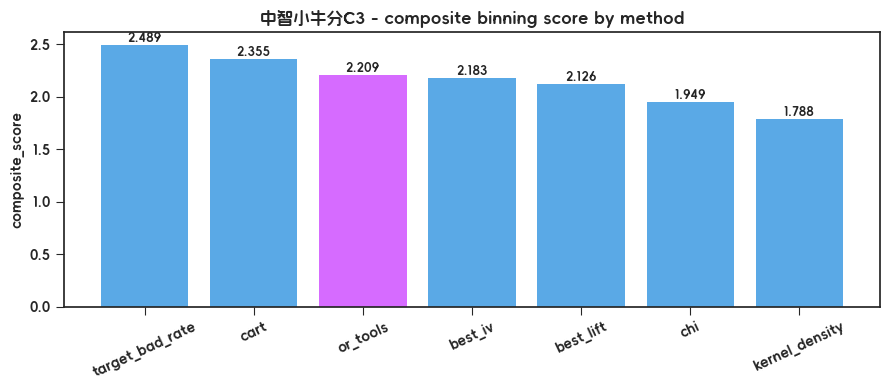

,method,n_bins,quadratic_lift,composite_score,zero_pair_count,splits,lift_seq,bad_rate_seq,rank,recommendation
0,target_bad_rate,5,0.4531,2.4893,0,"[492.0, 575.5, 676.0, 793.4]","[2.5661, 1.0519, 0.9254, 0.6438, 0.0]","[0.4286, 0.1757, 0.1545, 0.1075, 0.0]",1,推荐
1,cart,5,0.4857,2.3551,0,"[492.0, 544.5, 608.5, 689.0]","[2.5661, 1.3144, 1.0887, 0.7571, 0.4082]","[0.4286, 0.2195, 0.1818, 0.1264, 0.0682]",2,
2,or_tools,5,0.3073,2.2089,0,"[494.0, 544.5, 687.0, 777.76]","[2.3951, 1.3472, 0.8926, 0.5821, 0.0]","[0.4, 0.225, 0.1491, 0.0972, 0.0]",3,
3,best_iv,5,0.3210,2.1832,0,"[495.3, 593.0, 685.0, 793.4]","[2.2454, 1.131, 0.7485, 0.7392, 0.0]","[0.375, 0.1889, 0.125, 0.1235, 0.0]",4,
4,best_lift,5,0.5222,2.1259,0,"[494.0, 544.5, 605.0, 648.5]","[2.3951, 1.3472, 0.9979, 0.781, 0.5809]","[0.4, 0.225, 0.1667, 0.1304, 0.097]",5,
5,chi,5,0.2032,1.9492,0,"[495.3, 545.0, 608.5799, 699.44]","[2.2454, 1.3818, 1.0887, 0.8194, 0.2994]","[0.375, 0.2308, 0.1818, 0.1368, 0.05]",6,
6,kernel_density,5,0.1746,1.7876,0,"[498.0, 555.5, 608.5, 711.5]","[2.1133, 1.1975, 1.1975, 0.7275, 0.3522]","[0.3529, 0.2, 0.2, 0.1215, 0.0588]",7,


In [ ]:
from hscredit.core.metrics import quadratic_curve_coefficient, composite_binning_quality

compare_methods = [
    'kernel_density', 'chi', 'best_lift', 'cart',
    'target_bad_rate', 'best_iv', 'or_tools'
]

summary_rows = []
for method in compare_methods:
    params = dict(
        method=method,
        max_n_bins=5,
        min_n_bins=2,
        monotonic='descending',
        verbose=False,
        lift_refine=False,
    )
    if method == 'or_tools':
        params['time_limit'] = 10

    try:
        binner = OptimalBinning(**params)
        binner.fit(df[[feat]], df[target])
        table = binner.get_bin_table(feat)
        valid = table[table['分箱'] >= 0].reset_index(drop=True)
        bad_rates = valid['坏样本率'].to_numpy(dtype=float)
        lifts = valid['LIFT值'].to_numpy(dtype=float)
        bins = binner.transform(df[[feat]])[feat].to_numpy()
        zero_pair_count = int(np.sum((bad_rates[:-1] <= 1e-12) & (bad_rates[1:] <= 1e-12))) if len(bad_rates) > 1 else 0
        quad = quadratic_curve_coefficient(
            bins=bins,
            y=df[target].to_numpy(),
            metric='lift',
            monotonic='descending',
        )
        composite_score = composite_binning_quality(
            bins=bins,
            y=df[target].to_numpy(),
            metric='lift',
            monotonic='descending',
        )
        summary_rows.append({
            'method': method,
            'n_bins': len(valid),
            'quadratic_lift': round(float(quad), 6),
            'composite_score': round(float(composite_score), 6),
            'zero_pair_count': zero_pair_count,
            'splits': np.round(np.asarray(binner.splits_.get(feat, []), dtype=float), 4).tolist(),
            'lift_seq': np.round(lifts, 4).tolist(),
            'bad_rate_seq': np.round(bad_rates, 4).tolist(),
        })
    except Exception as e:
        summary_rows.append({
            'method': method,
            'n_bins': None,
            'quadratic_lift': None,
            'zero_pair_count': None,
            'splits': None,
            'lift_seq': None,
            'bad_rate_seq': None,
            'error': f'{type(e).__name__}: {e}',
        })

method_compare = pd.DataFrame(summary_rows).sort_values(
    by=['zero_pair_count', 'composite_score', 'quadratic_lift', 'n_bins'],
    ascending=[True, False, False, False],
    na_position='last'
).reset_index(drop=True)
method_compare['rank'] = np.arange(1, len(method_compare) + 1)
method_compare['recommendation'] = np.where(method_compare['rank'] == 1, '推荐', '')

display(method_compare[['rank', 'recommendation', 'method', 'n_bins', 'composite_score', 'quadratic_lift', 'zero_pair_count', 'splits', 'lift_seq', 'bad_rate_seq']])

plot_df = method_compare.dropna(subset=['quadratic_lift']).copy()
plt.figure(figsize=(9, 4))
bars = plt.bar(plot_df['method'], plot_df['composite_score'], color=['#d66bff' if m == 'or_tools' else '#5aa9e6' for m in plot_df['method']])
plt.title(f'{feat} - composite binning score by method')
plt.ylabel('composite_score')
plt.xticks(rotation=25)
for bar, value in zip(bars, plot_df['composite_score']):
    plt.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

method_compare


## 1. 快速开始 — 单特征分箱

In [ ]:
binner = OptimalBinning(method='quantile', max_n_bins=8)
binner.fit(df[[feat]], df[target])
bt = binner.bin_tables_[feat]
print(f'{feat} - IV: {bt["分档IV值"].sum():.4f}')
bt


中智小牛分C3 - IV: 0.5386


,分箱,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,0,"(-inf, 495.3]",16,10,6,0.0165,0.0124,0.0370,0.3750,1.0961,0.0270,0.5386,2.2454,0.0209,2.2454,0.0209,10,6,0.0247
1,1,"(495.3, 529.25]",23,20,3,0.0237,0.0248,0.0185,0.1304,-0.2902,0.0018,0.5386,0.7810,-0.0053,1.3818,0.0160,30,9,0.0184
2,2,"(529.25, 595.75]",76,61,15,0.0784,0.0755,0.0926,0.1974,0.2041,0.0035,0.5386,1.1818,0.0155,1.2496,0.0336,91,24,0.0355
3,3,"(595.75, 629.0]",37,31,6,0.0381,0.0384,0.0370,0.1622,-0.0353,0.0000,0.5386,0.9710,-0.0012,1.1818,0.0338,122,30,0.0342
4,4,"(629.0, 671.0]",39,34,5,0.0402,0.0421,0.0309,0.1282,-0.3100,0.0035,0.5386,0.7676,-0.0097,1.0972,0.0238,156,35,0.0230
5,5,"(671.0, 745.5]",77,69,8,0.0794,0.0854,0.0494,0.1039,-0.5477,0.0197,0.5386,0.6221,-0.0326,0.9607,-0.0150,225,43,0.0130
6,6,"(745.5, 793.4]",23,20,3,0.0237,0.0248,0.0185,0.1304,-0.2902,0.0018,0.5386,0.7810,-0.0053,0.9465,-0.0229,245,46,0.0193
7,7,"(793.4, +inf]",16,16,0,0.0165,0.0198,0.0000,0.0000,-24.1915,0.4790,0.5386,0.0000,-0.0168,0.8972,-0.0476,261,46,0.0391
8,-1,missing,663,547,116,0.6835,0.6770,0.7160,0.1750,0.0561,0.0022,0.5386,1.0476,0.1028,1.0000,0.0000,808,162,0.0000


## 2. 所有分箱方法对比

In [ ]:
X1 = df[[feat]]; y1 = df.loc[X1.index, target]
X1 = X1.reset_index(drop=True); y1 = y1.reset_index(drop=True)
methods = {
    'uniform': OptimalBinning(method='uniform', max_n_bins=8, monotonic='auto_asc_desc'),
    'quantile': OptimalBinning(method='quantile', max_n_bins=8, monotonic='auto_asc_desc'),
    'tree': OptimalBinning(method='tree', max_n_bins=8),
    'chi': OptimalBinning(method='chi', max_n_bins=8, monotonic='auto_asc_desc'),
    'best_ks': OptimalBinning(method='best_ks', max_n_bins=8, monotonic='auto_asc_desc'),
    'best_iv': OptimalBinning(method='best_iv', max_n_bins=8, monotonic='auto_asc_desc'),
    'best_lift': OptimalBinning(method='best_lift', max_n_bins=8, monotonic='auto_asc_desc'),
    'mdlp': OptimalBinning(method='mdlp', max_n_bins=8, monotonic='auto_asc_desc'),
    'cart': OptimalBinning(method='cart', max_n_bins=8, monotonic='auto_asc_desc'),
    'kmeans': OptimalBinning(method='kmeans', max_n_bins=8, monotonic='auto_asc_desc'),
    'smooth': OptimalBinning(method='smooth', max_n_bins=8, monotonic='auto_asc_desc'),
    'kernel_density': OptimalBinning(method='kernel_density', max_n_bins=8, monotonic='auto_asc_desc'),
    'target_bad_rate': OptimalBinning(method='target_bad_rate', max_n_bins=8, monotonic='auto_asc_desc'),
    'or_tools': OptimalBinning(method='or_tools', max_n_bins=8, monotonic='auto_asc_desc'),
    'monotonic': OptimalBinning(method='monotonic', max_n_bins=8, monotonic='auto_asc_desc'),
}
rows = []
for name, b in methods.items():
    try:
        b.fit(X1, y1)
        bt = b.bin_tables_.get(feat, pd.DataFrame())
        print(name)
        display(bt)
        iv_val = bt['分档IV值'].sum() if '分档IV值' in bt.columns else 0
        max_br = bt['坏样本率'].max() if '坏样本率' in bt.columns else np.nan
        rows.append({'方法': name, '分箱数': len(bt), 'IV': round(iv_val, 4), '最大坏样本率': round(float(max_br), 4) if pd.notna(max_br) else None})
    except Exception as e:
        rows.append({'方法': name, '分箱数': 0, 'IV': 0, '最大坏样本率': str(e)[:50]})

pd.DataFrame(rows).sort_values('IV', ascending=False)


uniform


,分箱,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,0,"(-inf, 512.25]",26,19,7,0.0268,0.0235,0.0432,0.2692,0.6084,0.0120,0.4655,1.6121,0.0169,1.6121,0.0169,19,7,0.0197
1,1,"(512.25, 560.5]",48,38,10,0.0495,0.0470,0.0617,0.2083,0.2720,0.0040,0.4655,1.2474,0.0129,1.3755,0.0310,57,17,0.0344
2,2,"(560.5, 589.5]",29,23,6,0.0299,0.0285,0.0370,0.2069,0.2632,0.0023,0.4655,1.2388,0.0074,1.3370,0.0400,80,23,0.0430
3,3,"(589.5, 608.75]",29,23,6,0.0299,0.0285,0.0370,0.2069,0.2632,0.0023,0.4655,1.2388,0.0074,1.3155,0.0497,103,29,0.0515
4,4,"(608.75, 705.25]",101,88,13,0.1041,0.1089,0.0802,0.1287,-0.3054,0.0088,0.4655,0.7707,-0.0267,1.0793,0.0251,191,42,0.0229
5,5,"(705.25, 801.75]",61,57,4,0.0629,0.0705,0.0247,0.0656,-1.0498,0.0481,0.4655,0.3926,-0.0408,0.9368,-0.0275,248,46,0.0230
6,6,"(801.75, +inf]",13,13,0,0.0134,0.0161,0.0000,0.0000,-23.9838,0.3859,0.4655,0.0000,-0.0136,0.8972,-0.0476,261,46,0.0391
7,-1,missing,663,547,116,0.6835,0.6770,0.7160,0.1750,0.0561,0.0022,0.4655,1.0476,0.1028,1.0000,0.0000,808,162,0.0000


quantile


,分箱,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,0,"(-inf, 495.3]",16,10,6,0.0165,0.0124,0.0370,0.3750,1.0961,0.0270,0.5623,2.2454,0.0209,2.2454,0.0209,10,6,0.0247
1,1,"(495.3, 564.5]",61,49,12,0.0629,0.0606,0.0741,0.1967,0.2001,0.0027,0.5623,1.1779,0.0119,1.3997,0.0345,59,18,0.0381
2,2,"(564.5, 593.0]",29,24,5,0.0299,0.0297,0.0309,0.1724,0.0384,0.0000,0.5623,1.0324,0.0010,1.2992,0.0367,83,23,0.0393
3,3,"(593.0, 704.0]",123,104,19,0.1268,0.1287,0.1173,0.1545,-0.0930,0.0011,0.5623,0.9249,-0.0109,1.0982,0.0303,187,42,0.0278
4,4,"(704.0, 793.4]",62,58,4,0.0639,0.0718,0.0247,0.0645,-1.0672,0.0503,0.5623,0.3863,-0.0419,0.9465,-0.0229,245,46,0.0193
5,5,"(793.4, +inf]",16,16,0,0.0165,0.0198,0.0000,0.0000,-24.1915,0.4790,0.5623,0.0000,-0.0168,0.8972,-0.0476,261,46,0.0391
6,-1,missing,663,547,116,0.6835,0.6770,0.7160,0.1750,0.0561,0.0022,0.5623,1.0476,0.1028,1.0000,0.0000,808,162,0.0000


tree


...

or_tools


,分箱,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,0,"(-inf, 494.0]",15,9,6,0.0155,0.0111,0.0370,0.4000,1.2015,0.0311,0.6443,2.3951,0.0219,2.3951,0.0219,9,6,0.0259
1,1,"(494.0, 544.5]",40,31,9,0.0412,0.0384,0.0556,0.2250,0.3702,0.0064,0.6443,1.3472,0.0149,1.6330,0.0380,40,15,0.0431
2,2,"(544.5, 610.5]",81,67,14,0.0835,0.0829,0.0864,0.1728,0.0413,0.0001,0.6443,1.0349,0.0032,1.2768,0.0451,107,29,0.0466
3,3,"(610.5, 687.0]",80,70,10,0.0825,0.0866,0.0617,0.1250,-0.3389,0.0084,0.6443,0.7485,-0.0226,1.0811,0.0232,177,39,0.0217
4,4,"(687.0, 777.76]",72,65,7,0.0742,0.0804,0.0432,0.0972,-0.6215,0.0231,0.6443,0.5821,-0.0335,0.9564,-0.0184,242,46,0.0156
5,5,"(777.76, +inf]",19,19,0,0.0196,0.0235,0.0000,0.0000,-24.3633,0.5729,0.6443,0.0000,-0.0200,0.8972,-0.0476,261,46,0.0391
6,-1,missing,663,547,116,0.6835,0.6770,0.7160,0.1750,0.0561,0.0022,0.6443,1.0476,0.1028,1.0000,0.0000,808,162,0.0000


monotonic


,分箱,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,0,"(-inf, 491.0]",11,6,5,0.0113,0.0074,0.0309,0.4545,1.4246,0.0334,0.4847,2.7217,0.0197,2.7217,0.0197,6,5,0.0234
1,1,"(491.0, 588.0]",91,73,18,0.0938,0.0903,0.1111,0.1978,0.2069,0.0043,0.4847,1.1844,0.0191,1.3502,0.0411,79,23,0.0442
2,2,"(588.0, 615.5]",39,33,6,0.0402,0.0408,0.0370,0.1538,-0.0978,0.0004,0.4847,0.9212,-0.0033,1.2315,0.0394,112,29,0.0404
3,3,"(615.5, 704.0]",88,75,13,0.0907,0.0928,0.0802,0.1477,-0.1456,0.0018,0.4847,0.8845,-0.0115,1.0982,0.0303,187,42,0.0278
4,4,"(704.0, 799.75]",65,61,4,0.0670,0.0755,0.0247,0.0615,-1.1176,0.0568,0.4847,0.3685,-0.0454,0.9368,-0.0275,248,46,0.0230
5,5,"(799.75, +inf]",13,13,0,0.0134,0.0161,0.0000,0.0000,-23.9838,0.3859,0.4847,0.0000,-0.0136,0.8972,-0.0476,261,46,0.0391
6,-1,missing,663,547,116,0.6835,0.6770,0.7160,0.1750,0.0561,0.0022,0.4847,1.0476,0.1028,1.0000,0.0000,808,162,0.0000


,方法,分箱数,IV,最大坏样本率
8,cart,7,0.7306,0.4286
12,target_bad_rate,7,0.7143,0.4286
6,best_lift,7,0.6917,0.4000
3,chi,7,0.6857,0.2857
13,or_tools,7,0.6443,0.4000
2,tree,7,0.5808,0.4000
7,mdlp,7,0.5663,0.3750
1,quantile,7,0.5623,0.3750
4,best_ks,8,0.5583,0.2727
10,smooth,6,0.5394,0.2093


## 3. 单调性约束分箱（外部评分）

In [ ]:
# 外部分字段示例：优先挑包含 C3 / 分 / score 的字段
cand = [c for c in features if any(k in str(c).lower() for k in ['c3', 'score', '分'])]
external_scores = cand[:4] if len(cand) >= 1 else [feat]
for score_feat in external_scores:
    valid = df[[score_feat]].dropna()
    y_v = df.loc[valid.index, target].reset_index(drop=True)
    X_v = valid.reset_index(drop=True)
    try:
        b = OptimalBinning(method='monotonic', monotonic='auto_asc_desc', max_n_bins=8)
        b.fit(X_v, y_v)
        bt = b.bin_tables_[score_feat]
        rates = bt['坏样本率'].round(4).tolist() if '坏样本率' in bt.columns else []
        ivv = bt['分档IV值'].sum() if '分档IV值' in bt.columns else 0
        print(f'{score_feat:20s} IV={ivv:.4f}  坏样本率走势: {rates}')
    except Exception as e:
        print(f'{score_feat}: {e}')


中智小牛分C3              IV=1.5041  坏样本率走势: [0.4545, 0.1978, 0.1538, 0.1477, 0.0615, 0.0]
极光欺诈分6v1             IV=0.1804  坏样本率走势: [0.1077, 0.1136, 0.1765, 0.1481, 0.2821]
轻花老客海纳子分V1           IV=0.2791  坏样本率走势: [0.05, 0.0897, 0.109, 0.1355, 0.1538, 0.2393, 0.3077, 0.35]
天创小额网贷分              IV=0.0614  坏样本率走势: [0.2177, 0.1424]


## 4. 批量分箱 — 行为特征

In [ ]:
num_feats = [c for c in features if pd.api.types.is_numeric_dtype(df[c])]
behavior_feats = num_feats[:12]
batcher = OptimalBinning(method='mdlp', max_n_bins=6)
batcher.fit(df[behavior_feats], df[target])
iv_rows = []
for f, bt in batcher.bin_tables_.items():
    if '分档IV值' in bt.columns:
        iv_rows.append({'特征': f, 'IV': round(bt['分档IV值'].sum(), 4), '分箱数': len(bt)})
pd.DataFrame(iv_rows).sort_values('IV', ascending=False)


,特征,IV,分箱数
2,CURRENT_DPD,4.0189,3
3,中智小牛分C3,0.5676,7
7,占信V3,0.2950,7
8,轻花老客海纳子分V1,0.2661,7
6,青云24,0.2208,6
1,放款金额,0.1303,5
10,近六个月非银多头机构数,0.1061,6
5,极光欺诈分6v1,0.0748,6
9,天创小额网贷分,0.0614,2
4,珊瑚92,0.0575,5


## 5. 自定义分割点

In [ ]:
# 自定义规则示例：用当前演示特征的分位点作为切分点
q = df[feat].dropna().quantile([0.2, 0.4, 0.6, 0.8]).values.tolist()
q


[550.0, 602.4, 663.6, 713.0]

In [ ]:
b_custom = OptimalBinning(user_splits={feat: q})
b_custom.fit(df[[feat]], df[target])
b_custom.bin_tables_[feat][['分箱标签','样本总数','样本占比','坏样本率','分档IV值']]


,分箱标签,样本总数,样本占比,坏样本率,分档IV值
0,"(-inf, 495.3]",16,0.0165,0.3750,0.0270
1,"(495.3, 550.0]",45,0.0464,0.2000,0.0024
2,"(550.0, 663.6]",123,0.1268,0.1626,0.0001
3,"(663.6, 713.0]",59,0.0608,0.1186,0.0084
4,"(713.0, +inf]",64,0.0660,0.0625,0.0546
5,missing,663,0.6835,0.1750,0.0022


## 6. 分箱可视化

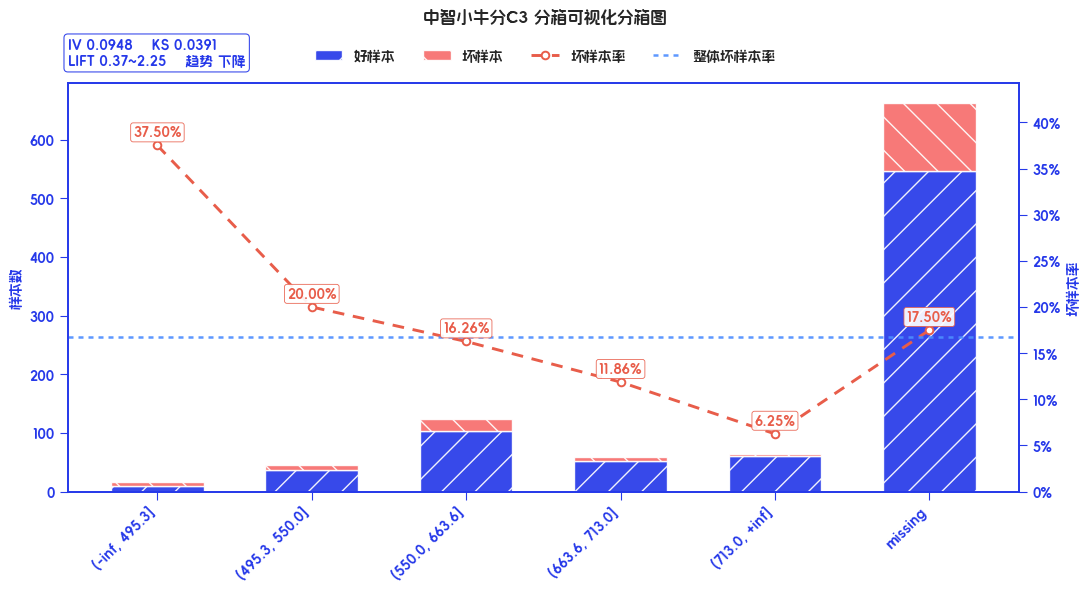

In [ ]:
from hscredit import bin_plot
b_vis = OptimalBinning(method='quantile', max_n_bins=5)
b_vis.fit(df[[feat]], df[target])
bin_plot(b_vis.bin_tables_[feat], desc=f'{feat} 分箱可视化', orientation='v', figsize=(11, 6));

## 7. WOE 转换

In [ ]:
top_feats = [feat] + [c for c in features if c != feat and pd.api.types.is_numeric_dtype(df[c])][:4]
b_woe = OptimalBinning(method='mdlp', max_n_bins=6)
b_woe.fit(df[top_feats].fillna(-999), df[target])
X_woe = b_woe.transform(df[top_feats].fillna(-999), metric='woe')
print('WOE转换结果:')
print(X_woe.head(3))
print('各特征WOE取值范围:')
for c in X_woe.columns:
    print(f'  {c}: [{X_woe[c].min():.3f}, {X_woe[c].max():.3f}]')


WOE转换结果:
   中智小牛分C3  客户编号   放款金额  CURRENT_DPD   珊瑚92
0   0.1013     0 0.0277      -2.2790 0.1021
1   0.1013     0 0.0277      -2.2790 0.1021
2   0.1013     0 0.0277      -2.2790 0.1021
各特征WOE取值范围:
  中智小牛分C3: [-1.351, 0.101]
  客户编号: [0.000, 0.000]
  放款金额: [-0.491, 1.607]
  CURRENT_DPD: [-2.279, 4.469]
  珊瑚92: [-0.604, 0.102]


## 8. 分箱方法基准对比（hscredit vs toad）

重点评估：head_lift、	ail_lift、edge_gap（头尾差）和 monotonic。


In [ ]:
from hscredit.report.feature_analyzer import benchmark_binning_methods

# 使用 hscredit_yyp.xlsx 的 C3 字段（若不存在，自动退化为 feat）
bench_feat = feat
for c in df.columns:
    if 'C3' in str(c) or 'c3' in str(c):
        bench_feat = c
        break

benchmark_df = benchmark_binning_methods(
    data=df,
    feature=bench_feat,
    overdue_col='MOB1',
    dpds=[3, 0],
    max_n_bins=5,
    min_bin_size=0.01,
    monotonic='auto_asc_desc',
)

benchmark_df[['method', 'dpd', 'n_bins', 'head_lift', 'tail_lift', 'edge_gap', 'monotonic', 'turns']]


,method,dpd,n_bins,head_lift,tail_lift,edge_gap,monotonic,turns
0,hscredit-cart,0,5,1.9389,0.0000,1.9389,True,0
1,hscredit-chi,0,5,1.9389,0.0000,1.9389,True,0
2,hscredit-tree,0,5,1.9389,0.0000,1.9389,True,0
3,hscredit-kmeans,0,5,1.9389,0.0000,1.9389,True,0
4,hscredit-quantile,0,5,1.9389,0.0000,1.9389,True,0
5,optbinning-cart,0,5,2.3025,0.3790,1.9235,True,0
6,optbinning-mdlp,0,2,1.2226,0.3790,0.8436,True,0
7,hscredit-best_ks,0,2,1.0563,0.4386,0.6178,True,0
8,hscredit-best_iv,0,2,1.0563,0.4386,0.6178,True,0
9,hscredit-mdlp,0,2,1.2814,0.8315,0.4499,True,0
